In [26]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("../../data/posts_by_time.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   post_id        450 non-null    str    
 1   post_title     450 non-null    str    
 2   time_posted    450 non-null    int64  
 3   0.5hr_score    438 non-null    float64
 4   0.5hr_ratio    438 non-null    float64
 5   0.5hr_comment  438 non-null    float64
 6   1hr_score      438 non-null    float64
 7   1hr_ratio      438 non-null    float64
 8   1hr_comment    438 non-null    float64
 9   2hr_score      438 non-null    float64
 10  2hr_ratio      438 non-null    float64
 11  2hr_comment    438 non-null    float64
 12  5hr_score      438 non-null    float64
 13  5hr_ratio      438 non-null    float64
 14  5hr_comment    438 non-null    float64
 15  24hr_score     422 non-null    float64
 16  24hr_ratio     422 non-null    float64
 17  24hr_comment   422 non-null    float64
 18  time           16 non

In [5]:
df = df.dropna(subset = '24hr_score')

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 422 entries, 3 to 444
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   post_id        422 non-null    str    
 1   post_title     422 non-null    str    
 2   time_posted    422 non-null    int64  
 3   0.5hr_score    422 non-null    float64
 4   0.5hr_ratio    422 non-null    float64
 5   0.5hr_comment  422 non-null    float64
 6   1hr_score      422 non-null    float64
 7   1hr_ratio      422 non-null    float64
 8   1hr_comment    422 non-null    float64
 9   2hr_score      422 non-null    float64
 10  2hr_ratio      422 non-null    float64
 11  2hr_comment    422 non-null    float64
 12  5hr_score      422 non-null    float64
 13  5hr_ratio      422 non-null    float64
 14  5hr_comment    422 non-null    float64
 15  24hr_score     422 non-null    float64
 16  24hr_ratio     422 non-null    float64
 17  24hr_comment   422 non-null    float64
 18  time           6 non-null 

In [11]:
df_current = pd.read_csv('../../data/check_posts_now.csv', index_col=0)

In [ ]:
df_current

In [15]:
df_merged = df.merge(df_current, on="post_id", how="left")

In [16]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   post_id               422 non-null    str    
 1   post_title            422 non-null    str    
 2   time_posted           422 non-null    int64  
 3   0.5hr_score           422 non-null    float64
 4   0.5hr_ratio           422 non-null    float64
 5   0.5hr_comment         422 non-null    float64
 6   1hr_score             422 non-null    float64
 7   1hr_ratio             422 non-null    float64
 8   1hr_comment           422 non-null    float64
 9   2hr_score             422 non-null    float64
 10  2hr_ratio             422 non-null    float64
 11  2hr_comment           422 non-null    float64
 12  5hr_score             422 non-null    float64
 13  5hr_ratio             422 non-null    float64
 14  5hr_comment           422 non-null    float64
 15  24hr_score            422 non-null

investigate growth / upvote velocity vs time trend. does it grow really quickly then plateau? etc.

In [17]:
df_merged["ratio_24h_to_current"] = (
    df_merged["24hr_score"] / df_merged["current_score"]
)

df_merged["ratio_current_to_24h"] = (
    df_merged["current_score"] / df_merged["24hr_score"]
)

In [18]:
df_merged['ratio_24h_to_current']

0      0.896552
1           NaN
2      0.833333
3      0.741627
4      0.712500
         ...   
417    1.250000
418    0.296703
419    1.000000
420    0.010235
421    1.016949
Name: ratio_24h_to_current, Length: 422, dtype: float64

In [25]:
df_merged[df_merged['ratio_24h_to_current'].isna()][['24hr_score', 'current_score']].sample(3)

,24hr_score,current_score
298,0.0,0
232,0.0,0
56,0.0,0


NaNs if both are 0 (dead posts)

In [27]:
df = df_merged.copy()

# Initialize column
df["ratio_current_to_24h"] = np.nan

# Valid normal cases (both > 0)
mask_valid = (df["24hr_score"] > 0) & (df["current_score"] > 0)

df.loc[mask_valid, "ratio_current_to_24h"] = (
    df.loc[mask_valid, "current_score"] /
    df.loc[mask_valid, "24hr_score"]
)

In [32]:
mask_late_growth = (df["24hr_score"] == 0) & (df["current_score"] > 0)

df.loc[mask_late_growth, "ratio_current_to_24h"] = np.nan
df["late_growth_flag"] = mask_late_growth

In [33]:
mask_both_zero = (df["24hr_score"] == 0) & (df["current_score"] == 0)

df.loc[mask_both_zero, "ratio_current_to_24h"] = 1.0

In [34]:
mask_invalid = (df["current_score"] == 0) & (df["24hr_score"] > 0)

df["invalid_flag"] = mask_invalid

In [36]:
df['ratio_current_to_24h'].describe()

count    416.000000
mean       1.520740
std        4.762722
min        0.500000
25%        1.069484
50%        1.189083
75%        1.350735
max       97.700000
Name: ratio_current_to_24h, dtype: float64

In [ ]:
import matplotlib.pyplot as plt

df['ratio_clipped'] = df['ratio_current_to_24h'].clip(upper=3)

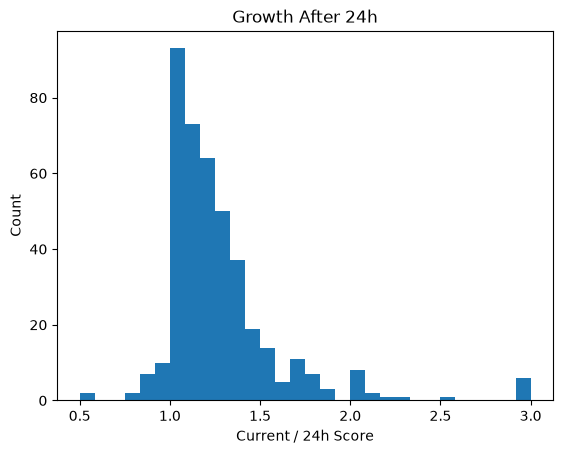

In [43]:
plt.hist(df['ratio_clipped'], bins=30)
plt.title("Growth After 24h")
plt.xlabel("Current / 24h Score")
plt.ylabel("Count")
plt.show()


Most posts stabilize early, but there is a consistent + right-tailed growth effect after 24h.

24h performance already captures most of the outcome, but still underestimates final performance.

investigating tail posts

In [44]:
tail = df[df['ratio_current_to_24h'] > 1.5]

In [49]:
tail.sort_values(by='ratio_current_to_24h', ascending=False).head(3)[['post_title', '24hr_score', 'current_score']]

,post_title,24hr_score,current_score
420,Vintage Deals on eBay: Sweaters for the Fall! ...,10.0,977
290,"LOWA Boots Men’s Toro Pro GTX Mid (Grey, Sz 8)...",1.0,9
385,[Woot] Helly Hansen YU 23 Reversible Puffer Bl...,2.0,15


ratios artifically inflate small posts (1 --> 9 is still considered bad)

In [50]:
df['24hr_score'].describe()

count    422.000000
mean      43.514218
std       46.065259
min        0.000000
25%       12.000000
50%       31.000000
75%       59.000000
max      277.000000
Name: 24hr_score, dtype: float64

In [53]:
df_filtered = df[df['24hr_score'] >= 30]

In [54]:
df_filtered["ratio_current_to_24h"] = (
    df_filtered["current_score"] / df_filtered["24hr_score"]
)

In [55]:
df_filtered['ratio_current_to_24h'].describe()

count    222.000000
mean       1.223850
std        0.224311
min        0.875000
25%        1.119136
50%        1.189083
75%        1.288889
max        3.578947
Name: ratio_current_to_24h, dtype: float64

In [57]:
df_filtered['is_breakout'] = df_filtered['ratio_current_to_24h'] >= 1.5



In [59]:
df_filtered[df_filtered['is_breakout']][['post_title','current_score','24hr_score']]

,post_title,current_score,24hr_score
103,Extra 20% off Arc'teryx Outlet sale items unti...,54,32.0
144,REI - Smartwool apparel and socks 25% off (fre...,48,32.0
317,Adidas Daily 3.0 Men's Shoes $22,55,35.0
323,ANIAN Clothing annual Thanksgiving sale 25% of...,59,33.0
335,"Timex Weekender watch 38mm $28.99, reg. $42.50...",55,35.0
369,NIKE Micah Parsons Dallas Cowboys Jersey - $39.99,59,31.0
386,Everlane Clearance Sale,68,31.0
401,Vintage Deals on eBay: Sweaters for the Fall! ...,408,114.0
404,Great deals on running shoes,234,151.0
